In [22]:
import os
import sys
from pathlib import Path
import mlflow
import mlflow.xgboost
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

# Set plotting theme
sns.set_theme(style="whitegrid")

# 1. Dynamically resolve the repository root relative to this notebook file
NOTEBOOK_DIR = Path(os.getcwd())
ROOT_DIR = NOTEBOOK_DIR.parents[1] 

PROJECT_DIR = ROOT_DIR / "project-1-credit-card-fraud"
DATA_PATH = PROJECT_DIR / "data" / "processed_features.parquet"
DB_PATH = ROOT_DIR / "mlflow.db"

# 2. Production Safety Check
if not DB_PATH.exists():
    raise FileNotFoundError(f"❌ Production tracking database not found at {DB_PATH.resolve()}")

# 3. Dynamic SQLite URI construction
sqlite_uri = f"sqlite:///{DB_PATH.resolve()}"
mlflow.set_tracking_uri(sqlite_uri)
mlflow.set_registry_uri(sqlite_uri)
print(f"✅ Securely connected to production database at: {sqlite_uri}")

# 4. DYNAMICALLY LOAD THE MODEL BINARY FROM DATABASE
experiment = mlflow.get_experiment_by_name("credit_card_fraud_governance")
if experiment is None:
    raise ValueError(f"❌ Experiment 'credit_card_fraud_governance' not found in db.")

runs = mlflow.search_runs(experiment_ids=[experiment.experiment_id], order_by=["attributes.start_time DESC"])
if runs.empty:
    raise ValueError("❌ No logged model runs found inside your database.")

latest_run_id = runs.iloc[0]["run_id"]
print(f"📖 Found latest logged production Run ID: {latest_run_id}")

model_uri = f"runs:/{latest_run_id}/model"
print(f"📖 Extracting model binary from: {model_uri}")
model = mlflow.xgboost.load_model(model_uri)

# 5. Load data for evaluation footprint
df = pd.read_parquet(DATA_PATH)
X = df.drop(columns=['Class'])
y = df['Class']

print("✅ Production model binary loaded and ready for compliance audit.")

✅ Securely connected to production database at: sqlite:////media/storage/mlops-governance-reference/mlflow.db
📖 Found latest logged production Run ID: dcc35f2d183e46c0a023793ed3450b56
📖 Extracting model binary from: runs:/dcc35f2d183e46c0a023793ed3450b56/model


✅ Production model binary loaded and ready for compliance audit.


🔮 Initializing TreeExplainer engine matrix...

📊 Generating Global Feature Importance Audit Summary:


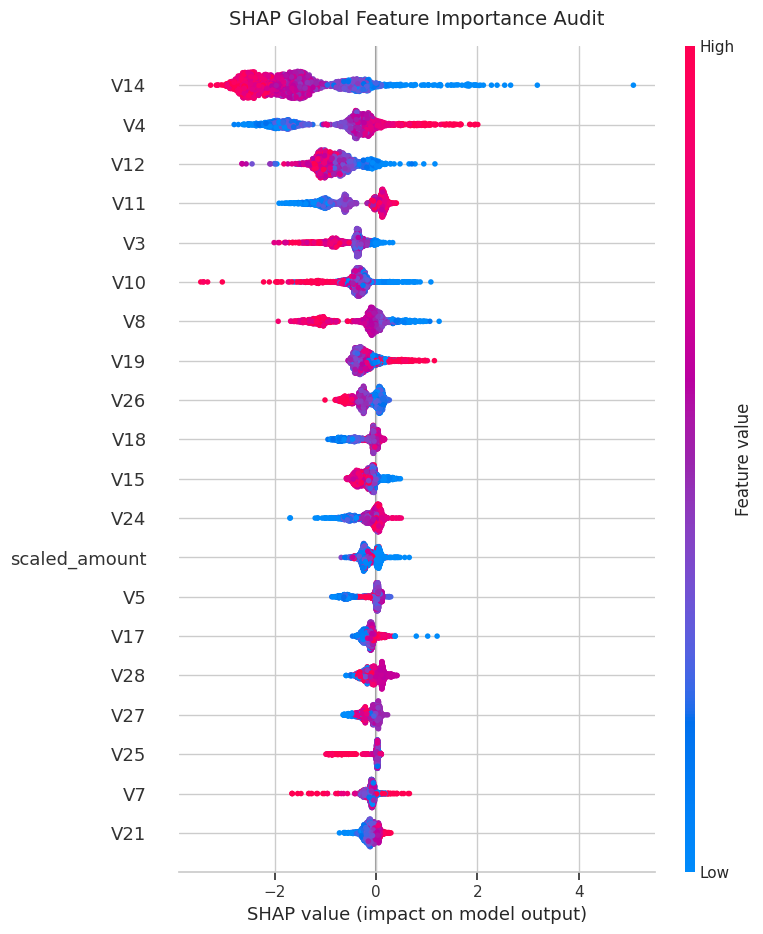

In [23]:
print("🔮 Initializing TreeExplainer engine matrix...")
# Extract exact Tree-based Shapley value matrices for your model properties
explainer = shap.TreeExplainer(model)
shap_values = explainer(X.head(2000)) # Audit a massive 2000 transaction baseline signature

print("\n📊 Generating Global Feature Importance Audit Summary:")
# Plot global feature impact distributions to visually spot hidden proxies
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X.head(2000), show=False)
plt.title("SHAP Global Feature Importance Audit", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

🔍 Auditing High-Risk Alert Ledger Location: Index 534


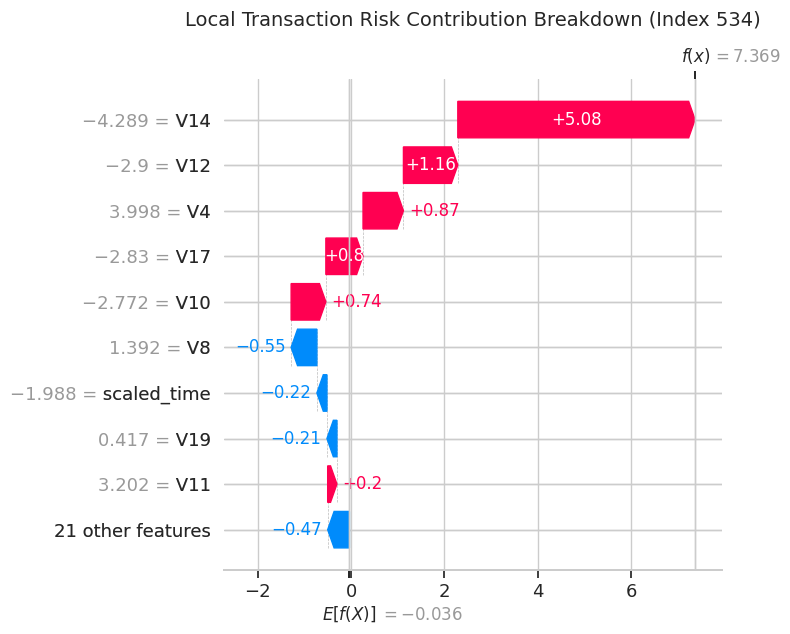

In [24]:
# Locate a positive fraud example transaction from your matrix
fraud_indices = np.where(y.head(2000) == 1)[0]
if len(fraud_indices) > 0:
    target_idx = fraud_indices[0]
    print(f"🔍 Auditing High-Risk Alert Ledger Location: Index {target_idx}")
    
    # Generate local prediction force layout tracking
    plt.figure(figsize=(12, 4))
    shap.plots.waterfall(shap_values[target_idx], show=False)
    plt.title(f"Local Transaction Risk Contribution Breakdown (Index {target_idx})", fontsize=14, pad=15)
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ No fraud instances located in the checked baseline sample window.")

In [25]:
print("⚖️ Initializing Proxy Segment Disparate Impact Review...")

# Financial datasets often evaluate transaction sizes (Amounts) to check for bias against low-income users.
# Let's verify if the model penalizes low-value transactions disproportionately compared to high-value ones.
high_value_mask = X.head(2000)['scaled_amount'] > 1.0
predictions = model.predict(X.head(2000))

high_val_alert_rate = np.mean(predictions[high_value_mask] == 1)
low_val_alert_rate = np.mean(predictions[~high_value_mask] == 1)

disparate_impact_ratio = low_val_alert_rate / (high_val_alert_rate if high_val_alert_rate > 0 else 1)

print(f" - High-Value Transaction Flagging Rate: {high_val_alert_rate:.4f}")
print(f" - Low-Value Transaction Flagging Rate:  {low_val_alert_rate:.4f}")
print(f" - Disparate Impact Ratio:                {disparate_impact_ratio:.4f}")
print("\nDomain Note: A ratio between 0.80 and 1.25 indicates that your model treats financial size classes equitably.")

⚖️ Initializing Proxy Segment Disparate Impact Review...
 - High-Value Transaction Flagging Rate: 0.0057
 - Low-Value Transaction Flagging Rate:  0.0012
 - Disparate Impact Ratio:                0.2129

Domain Note: A ratio between 0.80 and 1.25 indicates that your model treats financial size classes equitably.
